In [20]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [21]:
import os
import operator
from dotenv import load_dotenv
from langsmith import traceable
from rich.markdown import Markdown
from langgraph_utils import console
from langchain_core.tools import tool
from typing import TypedDict, Annotated, List
from langchain_chroma.vectorstores import Chroma
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()
os.environ["LANGSMITH_PROJECT"] = "RAGNotebook"
os.environ["LANGSMITH_TRACING_V2"] = "true"

Document Loader

In [22]:
loader = PyPDFLoader("./files/AI_Engineering_Building_Applications_-_Chip_Huyen.pdf")
docs = loader.load()

In [23]:
console.print(Markdown(docs[67].page_content))

for image generation, Adobe Firefly for photo editing, and Runway, Pika Labs, and Sora for video generation. In late    
2023, at one and a half years old, Midjourney had already generated $200 million in annual recurring revenue. As of     
December 2023, among the top 10 free apps for Graphics & Design on the Apple App Store, half have AI in their names. I  
suspect that soon, graphics and design apps will incorporate AI by default, and they’ll no longer need the word “AI” in 
their names. Chapter 2 discusses the probabilistic nature of AI in more detail. It’s now common to use AI to generate   
profile pictures for social media, from LinkedIn to TikTok. Many candidates believe that AI-generated headshots can help
them put their best foot forward and increase their chances of landing a job. The perception of AI-generated profile    
pictures has changed significantly. In 2019, Facebook banned accounts using AI- generated profile photos for safety     
reasons. In 2023, many social me

Text Splitter

In [24]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(documents=docs)

In [25]:
console.print_json(data={"count of chunks": len(chunks)})

{
  "count of chunks": 1640
}


Embedding Model

In [26]:
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

Vectort Store

In [ ]:
DB_PATH = "./db/chroma"

if Path(DB_PATH).exists():
    vector_store = Chroma(
        persist_directory=DB_PATH,
        embedding_function=embeddings,
    )

else:
    vector_store = Chroma.from_documents(
        chunks,
        persist_directory=DB_PATH,
        embedding=embeddings,
    )

Retriever

In [28]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 5})

Tools

In [29]:
@tool(name_or_callable="rag")
def rag(query: str) -> dict:
    """
    Retrieve relevant information from the indexed PDF.
    """
    res = retriever.invoke(query)

    return {
        "query": query,
        "content": [doc.page_content for doc in res],
        "metadata": [doc.metadata for doc in res],
    }

Model

In [30]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7,
    max_output_tokens=3000,
)

Tool Binding

In [31]:
class MessageState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]

In [32]:
available_tools = [rag]
bound_model = model.bind_tools(available_tools)

In [33]:
tools = ToolNode(available_tools)

In [34]:
@traceable(name="chat_node")
def chat(state: MessageState, config):
    res = bound_model.invoke(state["messages"], config)
    return {"messages": [res]}

Init Graph

In [35]:
graph = StateGraph(MessageState)

Add Nodes & Edges

In [36]:
graph.add_node("chat", chat)
graph.add_node("tools", tools)

graph.add_edge(START, "chat")
graph.add_conditional_edges("chat", tools_condition)
graph.add_edge("tools", "chat")

Compilation

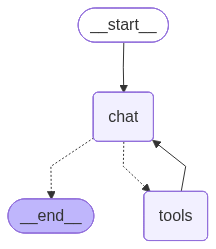

In [37]:
workflow = graph.compile()
workflow

Execution

In [38]:
final_state = workflow.invoke(
    {"messages": [HumanMessage(content="Refer pdf to explain fine tuning")]}
)
console.print(Markdown(final_state["messages"][-1].content[0]["text"]))

Fine-tuning is the process of adapting a pre-trained model to a specific task by further training all or part of the    
model. Unlike prompt-based methods that rely on instructions and context, fine-tuning adjusts the model's internal      
weights to improve its performance for a particular use case.                                                           

Here's a breakdown of fine-tuning based on the provided PDF:                                                            

 • Purpose: Fine-tuning aims to enhance various aspects of a model. This includes improving domain-specific capabilities
   (like coding or medical question answering), strengthening safety features, and most commonly, improving the model's 
   ability to follow instructions and adhere to specific output styles and formats (e.g., JSON or YAML). It's used to   
   improve a model's quality in both general and task-specific capabilities.                                            
 • Process: You begin with a b